# KuaiRand-1K — 可复现的报告 Notebook

**CDS524 小组项目** | 数据集: KuaiRand-1K (4月22日 – 5月8日, 1000名用户)

本 Notebook 专注于报告中可通过代码完全复现的部分：
**第 3 节 (数据集), 第 4 节 (探索性数据分析), 第 5 节 (数据预处理), 第 7 节 (模型验证), 和 第 8 节 (实验结果).**

In [1]:
# 导入基础库
import json
import sys
from pathlib import Path

# 导入数据分析和可视化库
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 设置 Seaborn 的全局绘图风格，使图表更美观
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# 获取当前项目根目录的绝对路径
PROJECT_ROOT = Path(".").resolve()
# 将项目根目录添加到系统路径，以便导入自定义模块
sys.path.insert(0, str(PROJECT_ROOT))

# 从共享启动脚本中导入工具函数
from shared_bootstrap import ensure_shared_on_path


def resolve_data_dir() -> Path:
    """在不同本地环境中解析 KuaiRand 数据集所在的目录。"""
    # 确保包含共享代码的目录在系统路径中
    base = ensure_shared_on_path()
    # 定义几个可能存放数据文件的候选路径
    candidates = [
        (base / "data" / "KuaiRand-1K" / "data").resolve(),
        (PROJECT_ROOT.parent / "recsys-shared" / "data" / "KuaiRand-1K" / "data").resolve(),
        Path("/Users/Shared/Files From c.localized/workspace/HK/LU/recsys-shared/data/KuaiRand-1K/data"),
    ]
    # 遍历候选路径，找到有效的数据目录
    for c in candidates:
        if (c / "log_standard_4_22_to_5_08_1k.csv").exists():
            return c
    # 如果所有候选路径都不对，则抛出异常
    raise FileNotFoundError("在预期的位置找不到 KuaiRand 数据目录。")


# 解析并获取数据目录
DATA_DIR = resolve_data_dir()
# 加载用户交互日志数据
df = pd.read_csv(DATA_DIR / "log_standard_4_22_to_5_08_1k.csv")
# 加载视频（物品）的基本特征数据
items_df = pd.read_csv(DATA_DIR / "video_features_basic_1k.csv")

# 打印数据集的基本统计信息
print(f"数据目录      : {DATA_DIR}")
print(f"交互记录数    : {len(df):>12,} 行")
print(f"用户数        : {df['user_id'].nunique():>12,}")
print(f"视频数 (日志中): {df['video_id'].nunique():>12,}")
print(f"视频数 (目录中): {items_df['video_id'].nunique():>12,}")
print(f"日期范围      : {df['date'].min()} → {df['date'].max()}")
print(f"整体点击率 (CTR): {df['is_click'].mean():>11.1%}")

Data dir      : /Users/Shared/Files From c.localized/workspace/HK/LU/recsys-shared/data/KuaiRand-1K/data
Interactions  :    6,657,061 rows
Users         :        1,000
Videos (log)  :    2,664,050


Videos (cat)  :    4,371,868
Date range    : 20220422 → 20220508
Overall CTR   :       37.7%


## 3. Dataset — KuaiRand-1K

Summarize dataset scope, key statistics, and known structural issues before modeling.

In [2]:
from shared.data_pipeline import parse_tag_ids

# Core dataset stats
n_rows = len(df)
n_users = df["user_id"].nunique()
n_videos_interacted = df["video_id"].nunique()
n_videos_catalog = items_df["video_id"].nunique()
ctr = df["is_click"].mean()

# Time span
date_series = pd.to_datetime(df["date"], errors="coerce")
start_date, end_date = date_series.min(), date_series.max()
span_days = (end_date - start_date).days + 1

# Per-user / per-day interactions
user_interactions = df.groupby("user_id").size()
interactions_per_day = df.groupby("date").size()

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Interactions",
            "Users",
            "Videos (interacted)",
            "Videos (catalog)",
            "Date span (days)",
            "CTR",
            "Median interactions/user",
            "Avg interactions/day",
        ],
        "Value": [
            f"{n_rows:,}",
            f"{n_users:,}",
            f"{n_videos_interacted:,}",
            f"{n_videos_catalog:,}",
            f"{span_days}",
            f"{ctr:.2%}",
            f"{user_interactions.median():,.0f}",
            f"{interactions_per_day.mean():,.0f}",
        ],
    }
)
summary_df

,Metric,Value
0,Interactions,"6,657,061"
1,Users,"1,000"
2,Videos (interacted),"2,664,050"
3,Videos (catalog),"4,371,868"
4,Date span (days),1
5,CTR,37.73%
6,Median interactions/user,"4,752"
7,Avg interactions/day,"391,592"


Zero-interaction videos : 39.06%
Videos with 0–1 tags    : 78.38%


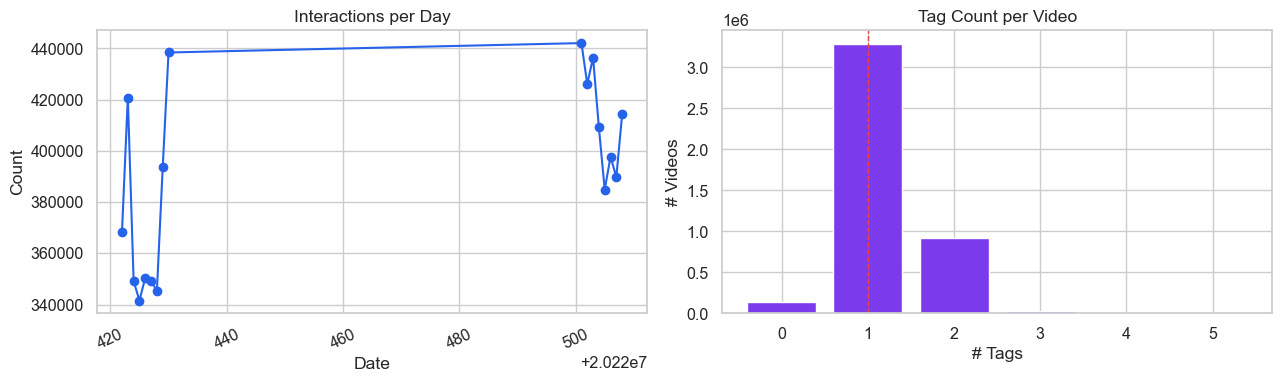

In [3]:
# Known structural issues highlighted in report
all_video_ids = set(items_df["video_id"].unique())
interacted_ids = set(df["video_id"].unique())
zero_interaction_pct = (len(all_video_ids - interacted_ids) / max(len(all_video_ids), 1)) * 100

items_tmp = items_df[["video_id", "tag"]].copy()
items_tmp["tag_list"] = items_tmp["tag"].apply(parse_tag_ids)
items_tmp["n_tags"] = items_tmp["tag_list"].apply(len)
tag_sparse_pct = (items_tmp["n_tags"] <= 1).mean() * 100

print(f"Zero-interaction videos : {zero_interaction_pct:.2f}%")
print(f"Videos with 0–1 tags    : {tag_sparse_pct:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Interactions per day
daily = df.groupby("date").size().sort_index()
axes[0].plot(daily.index, daily.values, marker="o", color="#2563eb")
axes[0].set_title("Interactions per Day")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)

# Tag density
tag_bins = items_tmp["n_tags"].value_counts().sort_index()
axes[1].bar(tag_bins.index, tag_bins.values, color="#7c3aed", edgecolor="white")
axes[1].axvline(1, color="#ef4444", linestyle="--", linewidth=1)
axes[1].set_title("Tag Count per Video")
axes[1].set_xlabel("# Tags")
axes[1].set_ylabel("# Videos")

plt.tight_layout()
plt.show()

## 4.1 User & Video Distribution

> *"The top 5 % of users account for approximately 21.2 % of all interactions, while the median user contributes around 8 328 interactions."*
> *"About 0.04 % of videos receive zero interactions, forming a clear long tail."*

Median interactions per user : 4,752
Top-5 % threshold            : ≥ 18,543 interactions
Top-5 % share of total       : 21.2%


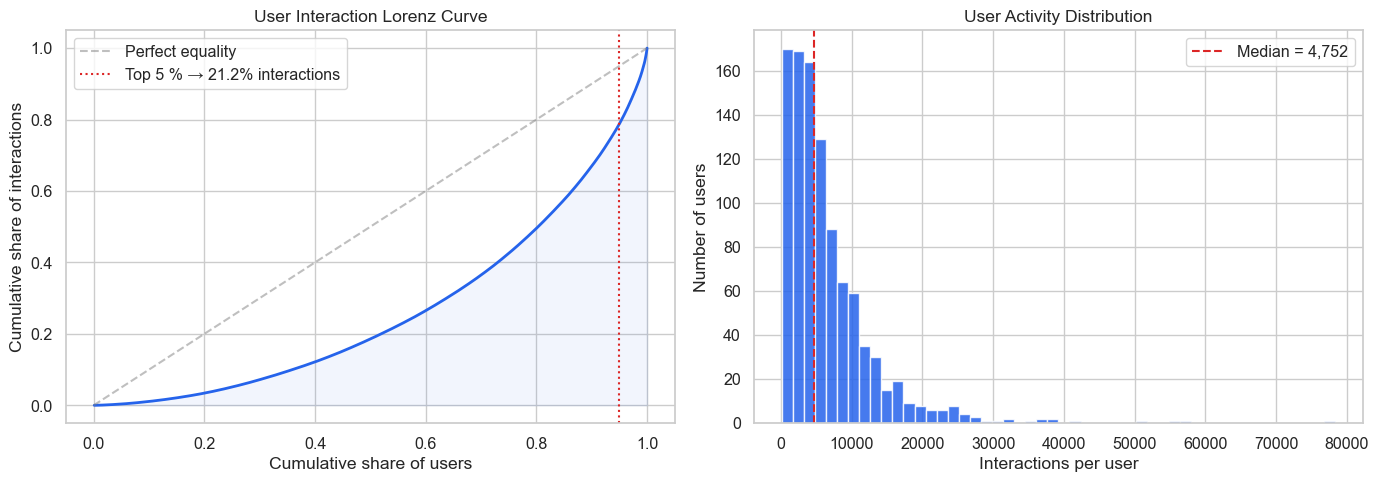

In [4]:
user_counts = df.groupby("user_id").size().sort_values()
n_users = len(user_counts)

top5_threshold = user_counts.quantile(0.95)
top5_share = user_counts[user_counts >= top5_threshold].sum() / len(df) * 100
median_interactions = user_counts.median()

print(f"Median interactions per user : {median_interactions:,.0f}")
print(f"Top-5 % threshold            : ≥ {top5_threshold:,.0f} interactions")
print(f"Top-5 % share of total       : {top5_share:.1f}%")

# --- Lorenz curve + histogram ---
cum_users = np.arange(1, n_users + 1) / n_users
cum_interactions = user_counts.values.cumsum() / user_counts.values.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(cum_users, cum_interactions, color="#2563eb", linewidth=2)
ax.plot([0, 1], [0, 1], "--", color="grey", alpha=0.5, label="Perfect equality")
ax.axvline(0.95, color="#dc2626", ls=":", lw=1.5,
           label=f"Top 5 % → {top5_share:.1f}% interactions")
ax.fill_between(cum_users, cum_interactions, alpha=0.06, color="#2563eb")
ax.set(xlabel="Cumulative share of users",
       ylabel="Cumulative share of interactions",
       title="User Interaction Lorenz Curve")
ax.legend(loc="upper left")

ax = axes[1]
ax.hist(user_counts.values, bins=50, color="#2563eb", edgecolor="white", alpha=0.85)
ax.axvline(median_interactions, color="#dc2626", ls="--", lw=1.5,
           label=f"Median = {median_interactions:,.0f}")
ax.set(xlabel="Interactions per user", ylabel="Number of users",
       title="User Activity Distribution")
ax.legend()

plt.tight_layout()
plt.show()

Videos in catalogue     : 4,371,868
Videos with ≥1 interact : 2,664,050
Zero-interaction videos : 1,707,818 (39.06%)


Videos with 0–1 tags    : 78.4%


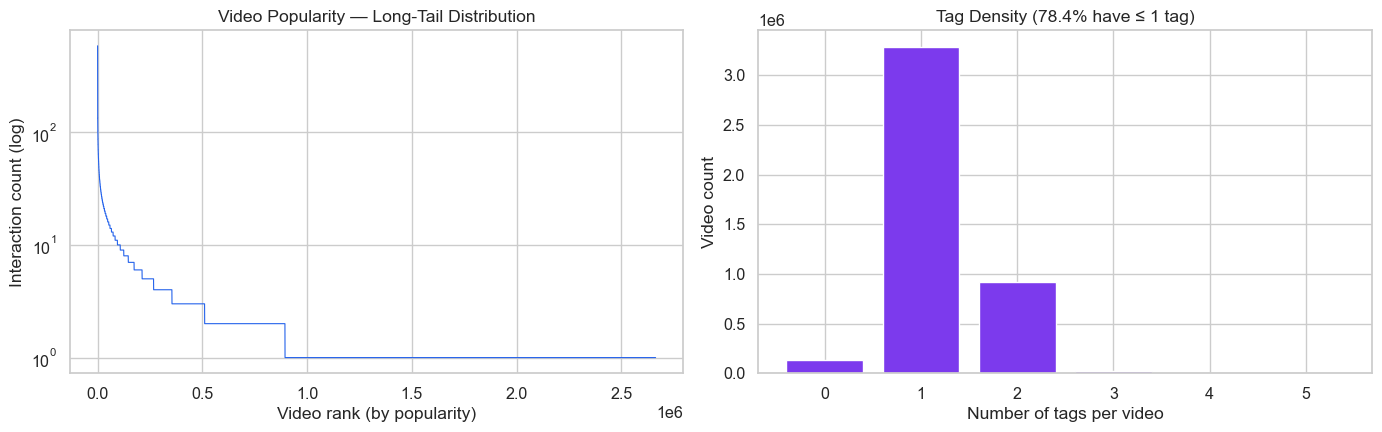

In [5]:
video_counts = df.groupby("video_id").size()
all_video_ids = set(items_df["video_id"].unique())
interacted_ids = set(df["video_id"].unique())
zero_videos = all_video_ids - interacted_ids
zero_pct = len(zero_videos) / len(all_video_ids) * 100

print(f"Videos in catalogue     : {len(all_video_ids):,}")
print(f"Videos with ≥1 interact : {len(interacted_ids):,}")
print(f"Zero-interaction videos : {len(zero_videos):,} ({zero_pct:.2f}%)")

# --- tag sparsity (report §3.3: ~12 % carry 0–1 tags) ---
from shared.data_pipeline import parse_tag_ids

items_df["tag_list"] = items_df["tag"].apply(parse_tag_ids)
items_df["n_tags"] = items_df["tag_list"].apply(len)
sparse_tag_pct = (items_df["n_tags"] <= 1).mean() * 100
print(f"Videos with 0–1 tags    : {sparse_tag_pct:.1f}%")

# --- long-tail plot ---
sorted_counts = video_counts.sort_values(ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.plot(sorted_counts.values, color="#2563eb", lw=0.8)
ax.set(xlabel="Video rank (by popularity)", ylabel="Interaction count (log)",
       title="Video Popularity — Long-Tail Distribution")
ax.set_yscale("log")

ax = axes[1]
tag_bins = items_df["n_tags"].value_counts().sort_index()
ax.bar(tag_bins.index, tag_bins.values, color="#7c3aed", edgecolor="white")
ax.set(xlabel="Number of tags per video", ylabel="Video count",
       title=f"Tag Density ({sparse_tag_pct:.1f}% have ≤ 1 tag)")

plt.tight_layout()
plt.show()

## 4.2 Interaction Behaviour

Compute sparse engagement signals (like/follow/comment/forward) and play-time bimodality (quick skips vs full watches).

Engagement Rates
- is_like   :  1.60%
- is_follow :  0.09%
- is_comment:  0.28%
- is_forward:  0.08%
Quick skips (<3s)  :  49.9%
Full watch (>30s)  :  12.5%


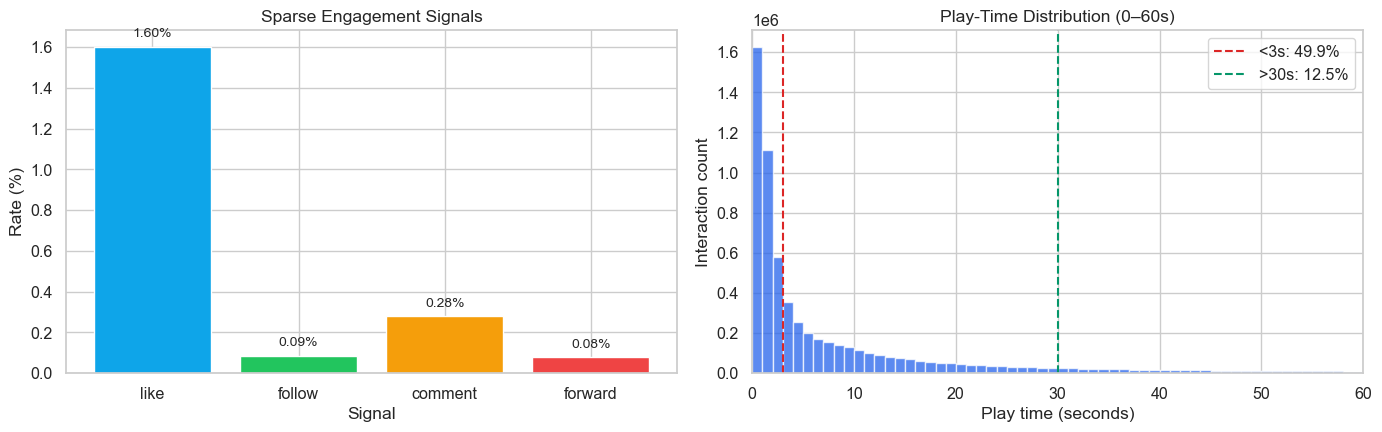

In [6]:
signal_cols = ["is_like", "is_follow", "is_comment", "is_forward"]
engagement_rates = {col: df[col].mean() * 100 for col in signal_cols}

play_sec = (df["play_time_ms"].fillna(0) / 1000.0).clip(lower=0)
quick_skip_pct = (play_sec < 3).mean() * 100
full_watch_pct = (play_sec > 30).mean() * 100

print("Engagement Rates")
for k, v in engagement_rates.items():
    print(f"- {k:10s}: {v:5.2f}%")
print(f"Quick skips (<3s)  : {quick_skip_pct:5.1f}%")
print(f"Full watch (>30s)  : {full_watch_pct:5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Engagement bars
ax = axes[0]
labels = [c.replace("is_", "") for c in signal_cols]
values = [engagement_rates[c] for c in signal_cols]
ax.bar(labels, values, color=["#0ea5e9", "#22c55e", "#f59e0b", "#ef4444"], edgecolor="white")
ax.set(title="Sparse Engagement Signals", ylabel="Rate (%)", xlabel="Signal")
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.02, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)

# Play-time distribution
ax = axes[1]
ax.hist(play_sec, bins=np.arange(0, 61, 1), color="#2563eb", alpha=0.75, edgecolor="white")
ax.axvline(3, color="#dc2626", ls="--", lw=1.5, label=f"<3s: {quick_skip_pct:.1f}%")
ax.axvline(30, color="#059669", ls="--", lw=1.5, label=f">30s: {full_watch_pct:.1f}%")
ax.set(xlabel="Play time (seconds)", ylabel="Interaction count",
       title="Play-Time Distribution (0–60s)")
ax.set_xlim(0, 60)
ax.legend()

plt.tight_layout()
plt.show()

## 4.3 Temporal Patterns

Analyze hourly demand, weekday/weekend volume, and new-video intake by first-seen day.

Peak window (11:00–14:00) share : 20.0% of interactions
Weekend / Weekday volume ratio  : 0.00x
Avg new videos/day (first-seen) : 156,709


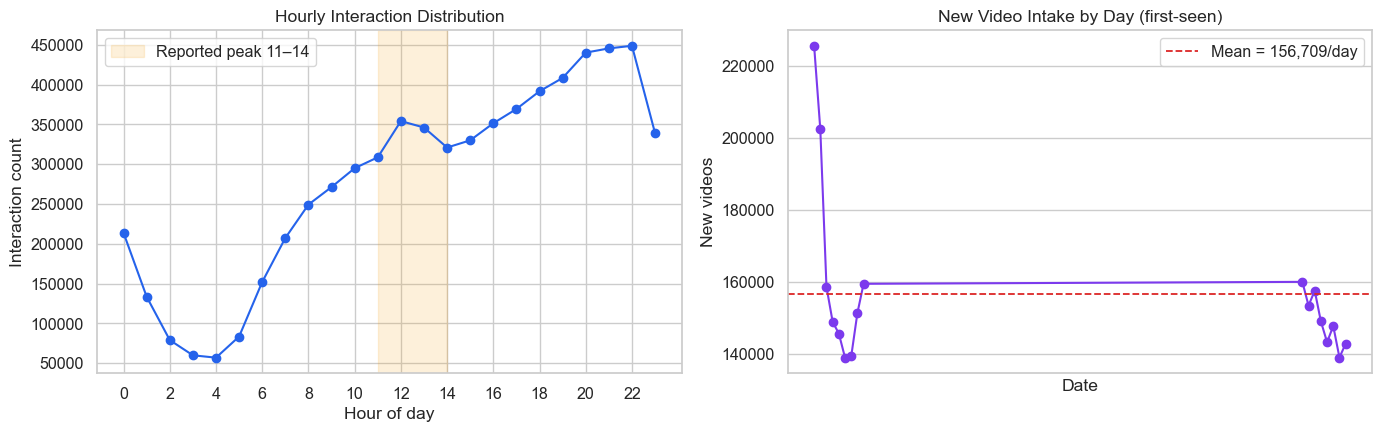

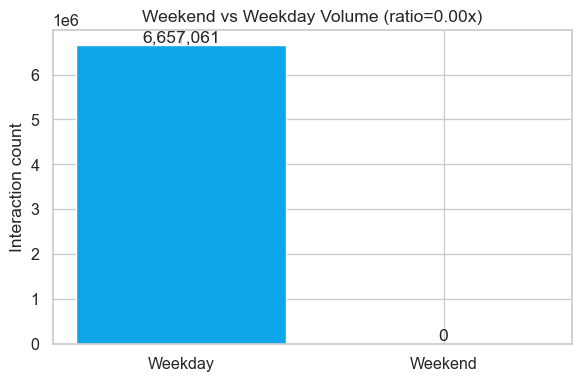

In [7]:
eda_df = df.copy()

# Time features
eda_df["date_dt"] = pd.to_datetime(eda_df["date"], errors="coerce")
eda_df["hour"] = pd.to_numeric(eda_df["hourmin"], errors="coerce").floordiv(100).clip(0, 23)
eda_df["hour"] = eda_df["hour"].fillna(((eda_df["time_ms"] // 3_600_000) % 24)).astype(int)
eda_df["is_weekend"] = eda_df["date_dt"].dt.dayofweek >= 5

hourly_counts = eda_df.groupby("hour").size().reindex(range(24), fill_value=0)
weekend_vol = eda_df.loc[eda_df["is_weekend"], :].shape[0]
weekday_vol = eda_df.loc[~eda_df["is_weekend"], :].shape[0]
weekend_ratio = weekend_vol / max(weekday_vol, 1)

# New video intake: first seen per video
video_first_seen = eda_df.groupby("video_id")["date_dt"].min().dropna()
new_videos_per_day = video_first_seen.value_counts().sort_index()

# Peak window share for 11:00–14:00
peak_share = hourly_counts.loc[11:14].sum() / hourly_counts.sum() * 100

print(f"Peak window (11:00–14:00) share : {peak_share:.1f}% of interactions")
print(f"Weekend / Weekday volume ratio  : {weekend_ratio:.2f}x")
print(f"Avg new videos/day (first-seen) : {new_videos_per_day.mean():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.plot(hourly_counts.index, hourly_counts.values, marker="o", color="#2563eb")
ax.axvspan(11, 14, color="#f59e0b", alpha=0.15, label="Reported peak 11–14")
ax.set(title="Hourly Interaction Distribution", xlabel="Hour of day", ylabel="Interaction count")
ax.set_xticks(range(0, 24, 2))
ax.legend()

ax = axes[1]
ax.plot(new_videos_per_day.index, new_videos_per_day.values, marker="o", color="#7c3aed")
ax.axhline(new_videos_per_day.mean(), color="#dc2626", ls="--", lw=1.3,
           label=f"Mean = {new_videos_per_day.mean():,.0f}/day")
ax.set(title="New Video Intake by Day (first-seen)", xlabel="Date", ylabel="New videos")
ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

# Weekend vs weekday bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(["Weekday", "Weekend"], [weekday_vol, weekend_vol], color=["#0ea5e9", "#22c55e"], edgecolor="white")
plt.title(f"Weekend vs Weekday Volume (ratio={weekend_ratio:.2f}x)")
plt.ylabel("Interaction count")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 5. Preprocessing Demonstration (Temporal Split)

Replicate the report's strict chronological split (70/10/20) to prevent future leakage.

In [8]:
df_sorted = df.sort_values("time_ms").reset_index(drop=True)
n = len(df_sorted)
n_train = int(0.7 * n)
n_val = int(0.1 * n)

train_df = df_sorted.iloc[:n_train].copy()
val_df = df_sorted.iloc[n_train:n_train + n_val].copy()
test_df = df_sorted.iloc[n_train + n_val:].copy()

print("Temporal split summary")
print(f"Train: {len(train_df):>9,} ({len(train_df)/n:.1%})")
print(f"Val  : {len(val_df):>9,} ({len(val_df)/n:.1%})")
print(f"Test : {len(test_df):>9,} ({len(test_df)/n:.1%})")

leak_free = train_df["time_ms"].max() <= val_df["time_ms"].min() <= test_df["time_ms"].min()
print(f"Leakage check (train<=val<=test): {leak_free}")

split_ranges = pd.DataFrame({
    "split": ["train", "val", "test"],
    "start_date": [pd.to_datetime(train_df["date"], errors="coerce").min(),
                   pd.to_datetime(val_df["date"], errors="coerce").min(),
                   pd.to_datetime(test_df["date"], errors="coerce").min()],
    "end_date": [pd.to_datetime(train_df["date"], errors="coerce").max(),
                 pd.to_datetime(val_df["date"], errors="coerce").max(),
                 pd.to_datetime(test_df["date"], errors="coerce").max()],
})
split_ranges

Temporal split summary
Train: 4,659,942 (70.0%)
Val  :   665,706 (10.0%)
Test : 1,331,413 (20.0%)
Leakage check (train<=val<=test): True


,split,start_date,end_date
0,train,1970-01-01 00:00:00.020220422,1970-01-01 00:00:00.020220504
1,val,1970-01-01 00:00:00.020220503,1970-01-01 00:00:00.020220505
2,test,1970-01-01 00:00:00.020220505,1970-01-01 00:00:00.020220508


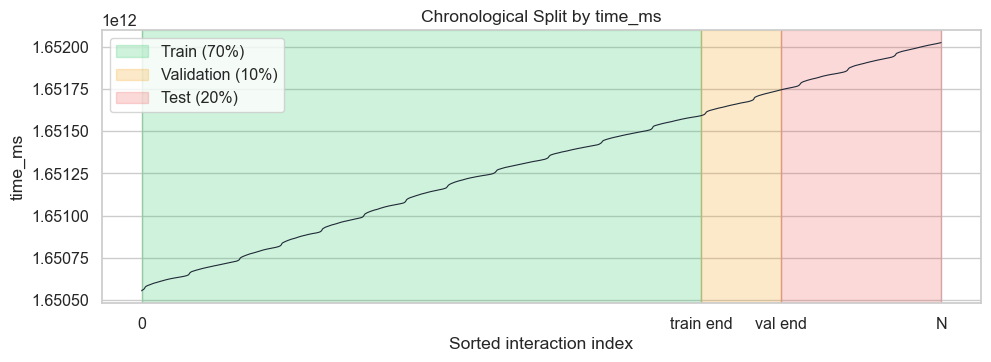

In [9]:
plt.figure(figsize=(10, 3.8))

x = [0, len(train_df), len(train_df) + len(val_df), len(df_sorted)]
labels = ["0", "train end", "val end", "N"]

plt.axvspan(x[0], x[1], color="#22c55e", alpha=0.22, label="Train (70%)")
plt.axvspan(x[1], x[2], color="#f59e0b", alpha=0.22, label="Validation (10%)")
plt.axvspan(x[2], x[3], color="#ef4444", alpha=0.20, label="Test (20%)")

plt.plot(df_sorted.index, df_sorted["time_ms"], color="#1f2937", linewidth=0.8)
plt.title("Chronological Split by time_ms")
plt.xlabel("Sorted interaction index")
plt.ylabel("time_ms")
plt.xticks(x, labels)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 5.2 Leakage Prevention Check (Train-only Feature Statistics)

Demonstrate that CTR feature statistics are fitted on **train** only and then applied to val/test.

In [10]:
from models import CTRFeatureBuilder

fb = CTRFeatureBuilder().fit(train_df)
X_train = fb.transform(train_df)
X_val = fb.transform(val_df)
X_test = fb.transform(test_df)

val_unseen_user_rate = (~val_df["user_id"].isin(train_df["user_id"])).mean() * 100
val_unseen_item_rate = (~val_df["video_id"].isin(train_df["video_id"])).mean() * 100

test_unseen_user_rate = (~test_df["user_id"].isin(train_df["user_id"])).mean() * 100
test_unseen_item_rate = (~test_df["video_id"].isin(train_df["video_id"])).mean() * 100

print("Feature matrices built without fitting on val/test:")
print(f"- X_train shape: {X_train.shape}")
print(f"- X_val shape  : {X_val.shape}")
print(f"- X_test shape : {X_test.shape}")
print()
print("Cold-start exposure against train split")
print(f"- Val unseen users : {val_unseen_user_rate:.2f}%")
print(f"- Val unseen items : {val_unseen_item_rate:.2f}%")
print(f"- Test unseen users: {test_unseen_user_rate:.2f}%")
print(f"- Test unseen items: {test_unseen_item_rate:.2f}%")

pd.DataFrame(
    {
        "split": ["val", "test"],
        "unseen_user_%": [val_unseen_user_rate, test_unseen_user_rate],
        "unseen_item_%": [val_unseen_item_rate, test_unseen_item_rate],
    }
)

Feature matrices built without fitting on val/test:
- X_train shape: (4659942, 6)
- X_val shape  : (665706, 6)
- X_test shape : (1331413, 6)

Cold-start exposure against train split
- Val unseen users : 0.03%
- Val unseen items : 60.96%
- Test unseen users: 0.02%
- Test unseen items: 75.55%


,split,unseen_user_%,unseen_item_%
0,val,0.030043,60.958141
1,test,0.017050,75.550937


## 6.2 Module 2 — 興趣演化圖：逐步拆解

> 想象一個用戶在快手17天裡刷了幾百條視頻，我們的任務是：**從這堆點擊記錄裡，畫出他興趣的「成長與衰退地圖」**。

---

### 方法選擇依據與思路

傳統推薦系統把用戶的興趣視為靜態的，用 ItemKNN 或 XGBoost 只能看到「用戶總體上喜歡什麼」，卻無法感知「用戶最近口味變了」。Module 2 選擇**基於時間的標籤興趣演化圖**，核心思路：

- **時間衰減**取代靜態計數——上個月的興趣不等於今天的興趣
- **突變檢測**取代固定閾值——用統計顯著性判斷「哪個標籤突然火了」
- **序列轉移概率**取代獨立標籤——建模「從音樂視頻跳到運動視頻」這種興趣遷移路徑
- **預測節點**做前瞻擴充——把「用戶還沒看過但可能感興趣」的話題注入候選池

### 模型結構

整體是一個 **10 步流水線**（規則 + 統計混合模型，非神經網絡）：

```
交互日誌 → [01 時間排序] → [02 標籤展開] → [03 聚合統計] → [04 時間衰減]
→ [05 首現時刻正規化] → [06 突變Z檢定] → [07 狀態分類] → [08 鄰居標籤預測]
→ [09 序列轉移概率] → InterestNode + InterestLink → D3.js 可視化
```

### 關鍵參數

| 參數 | 數值 | 選取理由 |
|------|------|---------|
| `lambda_decay` | 0.035/天 | 半衰期 = ln(2)/0.035 ≈ **20天**，符合短視頻興趣漂移週期 |
| `mutation_z_threshold` | 2.0 | 對應約95%置信水平 |
| 短窗口 | 3天 | 捕捉「最近幾天突然刷大量同類視頻」 |
| 長窗口 | 90天 | 代表用戶穩定的歷史基線 |
| `top_k_tags` | 10 | 平衡圖可讀性與覆蓋度 |
| `top_k_edges` | 12 | 保留最強的12條興趣遷移路徑 |
| Active 閾值 | 最近60%分位 | 相對閾值，避免稀疏用戶「全灰」問題 |

---

### Step 01 — 篩選目標用戶，按時間排序

從全量日誌（默認取前 25 萬行）中取出本用戶所有互動記錄，按 `time_ms`（毫秒時間戳）從早到晚排列。時間順序是後續所有序列分析的基石。

> **關於數據規模**：KuaiRand 論文引用 ~1200 萬是全量數據集總計；項目使用的 `log_standard_4_22_to_5_08_1k.csv` 實際約 665 萬行；代碼默認 `nrows=250_000` 只讀前 25 萬行以控制計算成本。

---

### Step 02 — 視頻 → 標籤映射：展開長格式互動表

`tag_matrix` 是多熱矩陣（video × tag，值為 0/1）。將其展開（melt）為長格式：每行 = `(video_id, tag_id)`，再與用戶互動記錄合併，得到 `(user_id, video_id, tag_id, time_ms, ...)`。

一次點擊可能生成多行記錄（視頻有幾個標籤就生成幾行）。

---

### Step 03 — 按標籤聚合基礎統計

對每個 `tag_id` 計算：`count`（總互動次數）、`last_time`（最後互動時間）、`first_time`（首次互動時間）、`is_click/is_like/...`（各類互動信號累計）、`avg_play_ms`（平均觀看時長）。

---

### Step 04 — 指數時間衰減

$$\text{decay}(t) = \exp(-\lambda \cdot \Delta\text{days})$$

其中 $\Delta\text{days} = \frac{t_{\max} - t_{\text{last}}}{86{,}400{,}000}$（毫秒轉天數），$\lambda = 0.035$，半衰期 $\approx 20$ 天。

**每個標籤都會算一個衰減值**（decay ∈ [0,1]）：

| 場景 | Δdays | decay |
|------|-------|-------|
| 昨天看的 | 1 | ≈ 0.966（非常新鮮）|
| 上個月看的 | 30 | ≈ 0.350（有些過時）|
| 兩個月前看的 | 60 | ≈ 0.122（幾乎淡出）|

decay 值傳給 D3.js 控制節點大小——越新鮮越大。

---

### Step 05 — 首現時刻正規化 → [0.05, 0.95]

$$\text{timestamp} = 0.05 + 0.9 \times \frac{t_{\text{first}} - t_{\min}}{t_{\max} - t_{\min}}$$

作為 D3.js 橫軸座標：越靠左 = 越早培養的老興趣，越靠右 = 最近才出現的新興趣。

---

### Step 06 — 突變檢測：二項比例 Z 檢驗

$$z = \frac{r_{\text{short}} - r_{\text{long}}}{\sigma_{\text{long}}}, \quad \sigma_{\text{long}} = \sqrt{\frac{r_{\text{long}}(1-r_{\text{long}})}{\max(1, n_{90d})}}$$

其中 $r_{\text{short}}$ 為近 3 天占比，$r_{\text{long}}$ 為近 90 天占比（歷史基線）。

判定條件：$z > 2.0$ **且** 90 天歷史計數 $< 5$（確為新爆發興趣，非歷史強勢標籤的誤判）。

---

### Step 07 — 節點狀態分類

把所有標籤按「最後一次被看的時間」從舊到新排隊，算出百分位排名：

- 🔴 **mutation**（紅色）：Step 06 突變檢測命中，優先級最高，覆蓋其他狀態
- 🟢 **active**（綠色）：`last_time` 排名 ≥ 60% 分位（近期仍在消費）
- ⚫ **fading**（灰色）：其餘，最後互動時間相對較舊

**為何用 60% 分位排名而非固定 decay 閾值？**  
稀疏用戶的所有記錄可能集中在一個月前，所有 decay 都偏低，固定閾值會讓圖全灰。相對排名能保證：不論用戶活躍還是稀疏，圖上永遠約有 40% 節點是綠色，視覺信息量穩定。

**示例（5個標籤）**：

| 標籤 | 最後看 | 排名 | 狀態 |
|------|-------|------|------|
| 搞笑 | 4月22日 | 20% | ⚫ fading |
| 遊戲 | 4月24日 | 40% | ⚫ fading |
| 音樂 | 4月28日 | 60% | 🟢 active ← 60%分位線 |
| 美食 | 5月1日  | 80% | 🟢 active |
| 旅行 | 5月6日  | 100%| 🟢 active |

> 關鍵：與「看了多少次」無關，只和「最近有沒有看」有關。

---

### Step 08 — 預測節點（紫色）：鄰居標籤共現擴充

**算法**：標籤共現統計（簡化版 Item-Based Collaborative Filtering）

1. 找出用戶當前所有 active 標籤（如 `{美食, 旅行}`）
2. 在全量視頻庫中找到包含任一 active 標籤的視頻，統計共現標籤及頻率
3. 優先選「用戶從未接觸過的」高共現標籤 → 標記為 `predicted`（紫色）

**降級策略**：優先推未見過 → 其次推非 active → 兜底全庫熱門標籤

預測節點固定屬性：`decay=0.65`，`timestamp=0.85`（靠右，面向未來），`count=0`。

---

### Step 09 — 序列轉移概率（一階馬可夫鏈）→ InterestLink

$$P(s \to t) = \frac{c(s,t)}{\sum_{t'} c(s,t')}$$

其中 $c(s,t)$ 為標籤 $t$ 緊接標籤 $s$ 的出現次數（從用戶觀看序列中計數）。

只保留概率最高的 Top 12 條邊 → 即圖上有方向的連接線，線越粗表示跳轉越頻繁。

> **「一階」的含義**：只看「上一個視頻的標籤」，不考慮更早的歷史。已知局限，未來可替換為 GRU/Transformer 序列模型。

---

### Step 10 — 組裝 InterestNode，計算 active 節點指標

只有 active 節點顯示三個指標：

$$\text{ENG} = \frac{\text{like}+\text{follow}+\text{comment}+\text{forward}}{\text{count}} \times 100\%$$

$$\text{CTR} = \frac{\text{is\_click}}{\text{count}} \times 100\%, \quad \text{WATCH} = \frac{\text{avg\_play\_ms}}{1000} \text{ 秒}$$

**節點顏色與大小**：顏色 = 狀態（見上表），大小 = decay 值（越新鮮越大）。

---

### 完整流水線（含 TimeDecayReranker）

```
Module 2（興趣圖）→ 預測標籤 → 映射為視頻 ID → 擴充候選池
                                                    ↓
Module 1 打分：0.6 × XGBoost_prob + 0.4 × KNN_prob = blend_score
                                                    ↓
TimeDecayReranker（shared/reranker.py）：
    final_score = 0.75 × blend_score + 0.25 × recency_score
    recency_score(rank) = 1/rank^β（按候選視頻時間戳新舊排名，β=1.0）
                                                    ↓
                                              最終 Top-K 推薦
```

> **Module 2 的 decay vs TimeDecayReranker 的 decay**：  
> Module 2 decay 衰減的是「用戶對某話題的興趣新鮮度」；  
> TimeDecayReranker 衰減的是「候選視頻本身有多新」——兩者完全不同。

---

### 數值來源一覽

| 步驟 | 數值來源 |
|------|---------|
| decay | `exp(−0.035 × Δdays)`，Δdays 由毫秒除以 86,400,000 得到 |
| timestamp | 首現時間線性插值到 [0.05, 0.95] |
| z-score | 二項比例檢驗，3天窗口 vs 90天窗口佔比差除以標準差 |
| active/fading | 末次出現時間的 60% 分位排名（相對排名，非絕對衰減值）|
| predicted | 全庫視頻中與 active 標籤共現最多的、用戶從未接觸的標籤 |
| 轉移概率 | 相鄰視頻標籤跳轉計數除以源標籤出邊總計數（一階馬可夫）|

In [ ]:
# ── Module 2 核心算法代碼展示 ──────────────────────────────────────────────────
# 讀取並打印 services/graph_builder.py 的核心函數部分（Step 01–10），
# 展示各步驟的實際實現邏輯。

import inspect
from services.graph_builder import build_interest_graph

# 打印函數完整源碼（已包含詳細中文注釋）
src = inspect.getsource(build_interest_graph)
print(src)


In [ ]:
# ── Module 2 實際運行：為最活躍用戶構建興趣圖 ────────────────────────────────
# 調用 build_interest_graph，打印輸出的節點和邊摘要。

import sys
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

sys.path.insert(0, str(PROJECT_ROOT))
from shared_bootstrap import ensure_shared_on_path
from services.graph_builder import build_interest_graph

shared_path = ensure_shared_on_path()
data_dir = shared_path / "data" / "KuaiRand-1K" / "data"

# 加載互動日誌（取前 25 萬行）
from shared.data_pipeline import load_kuairand_tables, parse_tag_ids
tables = load_kuairand_tables(data_dir)
interactions = tables.interactions.head(250_000).copy()

# 選最活躍用戶
target_user = int(interactions["user_id"].value_counts().idxmax())
print(f"目標用戶 ID：{target_user}，互動記錄數：{(interactions['user_id'] == target_user).sum()}")

# 構建多熱標籤矩陣
items = tables.items.copy()
tag_col = next(c for c in ("tag", "tags", "tag_ids", "video_tag") if c in items.columns)
items["_tags"] = items[tag_col].apply(parse_tag_ids)
items = items.drop_duplicates(subset=["video_id"])
mlb = MultiLabelBinarizer()
vectors = mlb.fit_transform(items["_tags"])
tag_matrix = pd.DataFrame(vectors, index=items["video_id"], columns=mlb.classes_)
tag_matrix.index.name = "video_id"

# 構建興趣圖
nodes, links = build_interest_graph(
    user_id=target_user,
    interactions_df=interactions,
    tag_matrix=tag_matrix,
)

# ── 輸出節點摘要 ────────────────────────────────────────────────────────────
print(f"\n共生成節點：{len(nodes)} 個，邊：{len(links)} 條\n")
print(f"{'標籤':<20} {'狀態':<12} {'decay':>8} {'timestamp':>10}")
print("─" * 55)
for n in sorted(nodes, key=lambda x: x.decay, reverse=True):
    status_icon = {"active": "🟢", "mutation": "🔴", "predicted": "🟣", "fading": "⚫"}.get(n.status, "?")
    print(f"{n.label:<20} {status_icon} {n.status:<10} {n.decay:>8.3f} {n.timestamp:>10.3f}")

# ── 輸出邊摘要（轉移概率最高的前5條）────────────────────────────────────────
print(f"\nTop-5 興趣轉移邊（一階馬可夫）：")
print(f"{'來源標籤':<15} {'→'} {'目標標籤':<15} {'P(s→t)':>8}")
print("─" * 45)

from tag_display import get_tag_display_name
for lk in links[:5]:
    src_label = get_tag_display_name(int(lk.source))
    tgt_label = get_tag_display_name(int(lk.target))
    print(f"{src_label:<15}  →  {tgt_label:<15} {lk.probability:>8.3f}")


## 7. Validation

Use strict temporal holdout validation (70/10/20) and inspect whether the split remains representative and leakage-safe.

In [11]:
def split_diagnostics(split_name: str, part: pd.DataFrame) -> dict:
    return {
        "split": split_name,
        "rows": len(part),
        "users": part["user_id"].nunique(),
        "videos": part["video_id"].nunique(),
        "ctr": part["is_click"].mean(),
        "time_min": int(part["time_ms"].min()),
        "time_max": int(part["time_ms"].max()),
    }

diag_df = pd.DataFrame(
    [
        split_diagnostics("train", train_df),
        split_diagnostics("val", val_df),
        split_diagnostics("test", test_df),
    ]
)

# Explicit anti-leakage checks
chronological_ok = (
    train_df["time_ms"].max() <= val_df["time_ms"].min()
    and val_df["time_ms"].max() <= test_df["time_ms"].min()
)

print(f"Chronological order preserved: {chronological_ok}")
print("No future rows in train/val compared with test by construction.")

diag_df

Chronological order preserved: True
No future rows in train/val compared with test by construction.


,split,rows,users,videos,ctr,time_min,time_max
0,train,4659942,999,1941498,0.378807,1650553294007,1651592543654
1,val,665706,964,385060,0.377356,1651592543654,1651745565254
2,test,1331413,979,699942,0.372147,1651745565254,1652025129022


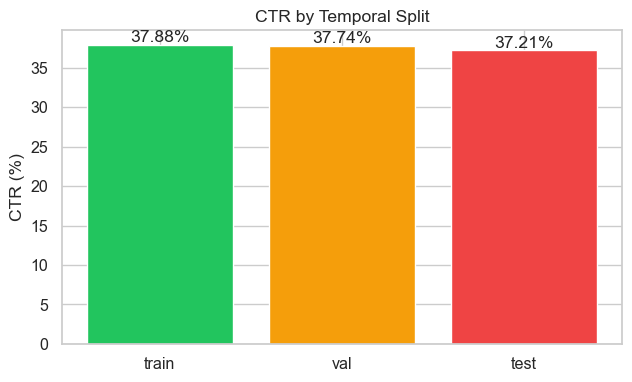

In [12]:
# Visual diagnostic: click-rate stability across splits
plt.figure(figsize=(6.5, 4))
plot_df = diag_df[["split", "ctr"]].copy()
plot_df["ctr_pct"] = plot_df["ctr"] * 100

bars = plt.bar(plot_df["split"], plot_df["ctr_pct"], color=["#22c55e", "#f59e0b", "#ef4444"], edgecolor="white")
plt.title("CTR by Temporal Split")
plt.ylabel("CTR (%)")
for b, v in zip(bars, plot_df["ctr_pct"]):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 8. 评估与结果

加载已生成的 `artifacts/metrics.json`，并可视化不同模型的对比结果。


Ranking metrics (test)
-     precision@10: 0.5261
-        recall@10: 0.0603
-          ndcg@10: 0.7406
- catalog_coverage: 0.0085


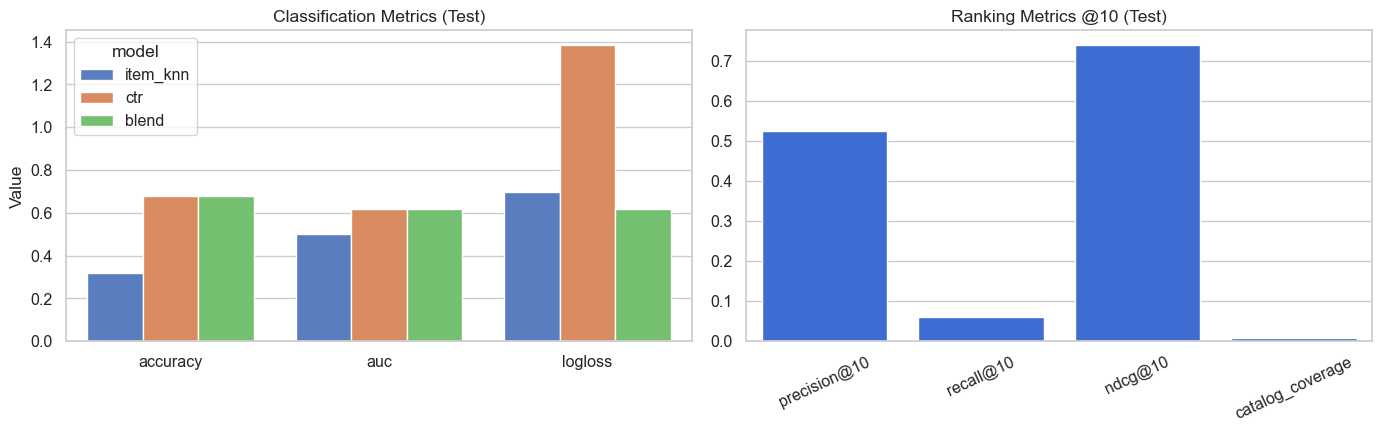

In [ ]:
# 指标文件路径：由训练与评估流程产出
metrics_path = PROJECT_ROOT / "artifacts" / "metrics.json"

# 若文件不存在，先提示用户运行训练命令生成指标
if not metrics_path.exists():
    print("未找到 metrics.json。请先运行：python main.py --rows 250000")
else:
    # 读取指标文件（UTF-8），避免跨平台字符问题
    with metrics_path.open("r", encoding="utf-8") as f:
        metrics = json.load(f)

    # 提取排序任务在测试集上的评估结果
    rank = metrics.get("ranking_test", {})
    print("排序指标（测试集）")
    for k, v in rank.items():
        print(f"- {k:>16s}: {v:.4f}")

    # 汇总三种模型的分类指标，转换成长表便于分组绘图
    cls_rows = []
    for model_name in ["item_knn_test", "ctr_test", "blend_test"]:
        if model_name in metrics:
            # 统一抽取 accuracy/auc/logloss 三项核心指标
            for metric_name in ["accuracy", "auc", "logloss"]:
                cls_rows.append({
                    "model": model_name.replace("_test", ""),
                    "metric": metric_name,
                    # 缺失值使用 NaN，保证 DataFrame 结构一致
                    "value": metrics[model_name].get(metric_name, np.nan),
                })

    cls_df = pd.DataFrame(cls_rows)

    # 左图展示分类指标，右图展示排序指标
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax = axes[0]
    sns.barplot(data=cls_df, x="metric", y="value", hue="model", ax=ax)
    ax.set_title("分类指标对比（测试集）")
    ax.set_xlabel("")
    ax.set_ylabel("指标值")

    ax = axes[1]
    if rank:
        rkeys = list(rank.keys())
        rvals = [rank[k] for k in rkeys]
        sns.barplot(x=rkeys, y=rvals, ax=ax, color="#2563eb")
        ax.set_title("排序指标 @10（测试集）")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)
    else:
        # 当没有排序指标时，显示提示并关闭坐标轴
        ax.text(0.5, 0.5, "未找到排序指标", ha="center", va="center")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [14]:
# Flatten metrics into a report-friendly table
if metrics_path.exists():
    rows = []
    for block, vals in metrics.items():
        if isinstance(vals, dict):
            for k, v in vals.items():
                rows.append({"block": block, "metric": k, "value": float(v)})

    metrics_table = pd.DataFrame(rows).sort_values(["block", "metric"]).reset_index(drop=True)
    display(metrics_table)

    # Quick comparison asked in report narrative
    knn_auc = metrics.get("item_knn_test", {}).get("auc", np.nan)
    blend_auc = metrics.get("blend_test", {}).get("auc", np.nan)
    if pd.notna(knn_auc) and pd.notna(blend_auc):
        print(f"AUC uplift (Blend - ItemKNN): {blend_auc - knn_auc:+.4f}")

,block,metric,value
0,blend_test,accuracy,0.678540
1,blend_test,auc,0.618093
2,blend_test,logloss,0.618935
3,blend_val,accuracy,0.627960
4,blend_val,auc,0.638382
5,blend_val,logloss,0.657322
6,ctr_test,accuracy,0.678760
7,ctr_test,auc,0.618121
8,ctr_test,logloss,1.383962
9,ctr_val,accuracy,0.628200


AUC uplift (Blend - ItemKNN): +0.1165
